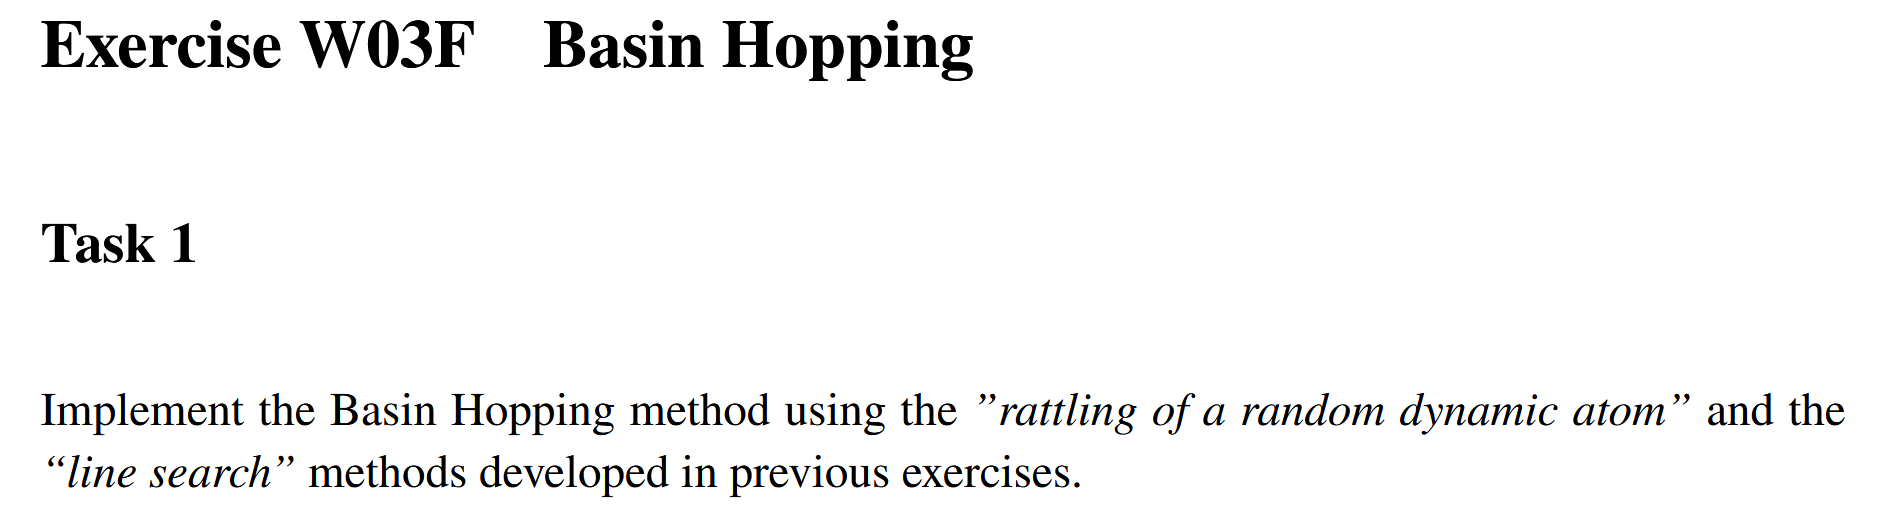

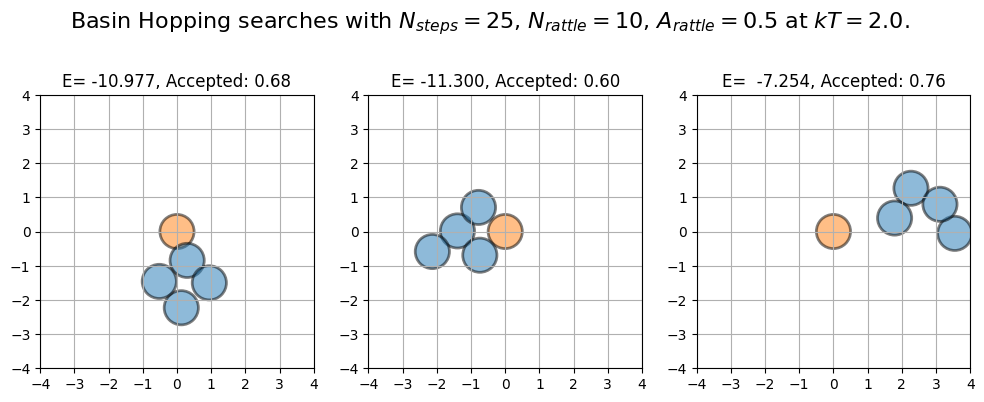

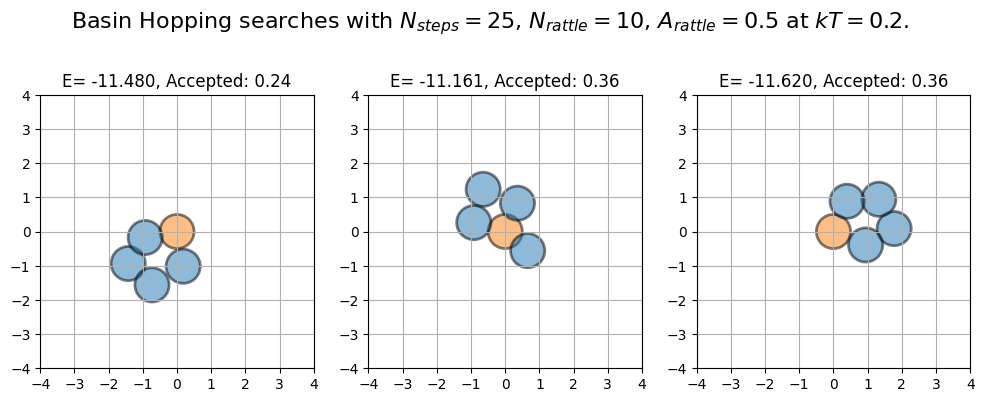

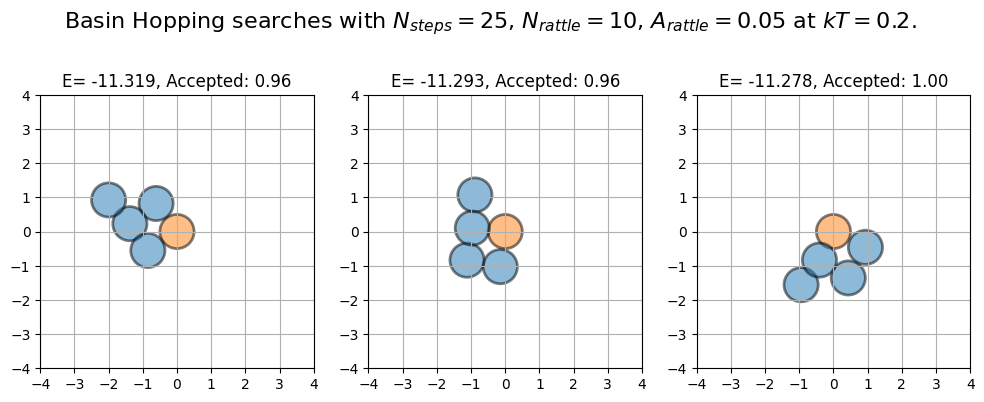

In [31]:
import numpy as np 
import matplotlib.pyplot as plt 
from week03 import *

from scipy.optimize import fmin

class ModifiedMorseForce(ModifiedMorse):
    def forces(self, pos, delta=1e-6):
        N, dim = pos.shape
        forces = np.zeros(pos.shape)
        for i in range(N):
            for d in range(dim):
                # Positive displacement
                pos_forward = np.array(pos, copy=True)
                pos_forward[i, d] += delta
                e_forward = self.potential_energy(pos_forward)

                # Negative displacement
                pos_backward = np.array(pos, copy=True)
                pos_backward [i, d] -= delta
                e_backward = self.potential_energy(pos_backward)

                # Central difference
                forces[i, d] = -(e_forward - e_backward) / (2 * delta)
        
        return forces

class AtomicCluster(AtomicClusterBase2):

    def rattle_random_dynamic_atom(self, A=0.01):
        index = np.random.choice(self.indices_dynamic_atoms)
        self.pos[index] += np.random.normal(scale=A, size=2)

def line_search(cluster, steps=20, fnorm_min=1e-4, xtol=1e-6, ftol=1e-6):
    test = cluster.copy()

    points = [cluster.get_positions()[0].copy()]
    
    def potential_energy_of_alpha(alpha, p):
        # Test position is the current position plus the step (alpha) times direction (p)
        test.set_positions(cluster.get_positions() + alpha * p)
        return test.potential_energy
        
    for i in range(steps):
        f = cluster.forces
        fnorm = np.linalg.norm(f)
        
        if fnorm < fnorm_min:
            break # Done

        # Normalized direction    
        p = f / fnorm
        
        alpha_opt = fmin(lambda alpha: potential_energy_of_alpha(alpha, p), 0.1, disp=False, xtol=xtol, ftol=ftol)
        
        cluster.set_positions(cluster.get_positions() + alpha_opt * p)
        
        points.append(cluster.get_positions()[0].copy())
        
    return np.array(points).transpose()


def basin_hopping(cluster, Nsteps=5, kT=0.5, Nrattle=5, Arattle=0.5):
    test = cluster.copy()
    Naccept = 0
    for _ in range(Nsteps):
        test.set_positions(cluster.get_positions())
        for _ in range(Nrattle):
            test.rattle_random_dynamic_atom(A=Arattle)
        line_search(test)
        de = test.potential_energy - cluster.potential_energy
        if np.random.rand() < np.exp(-de / kT): 
            cluster.set_positions(test.get_positions())
            Naccept += 1
    return Naccept/Nsteps

def simulate(file, Nfigs=3, Natoms=5, Nsteps=5, kT=0.5, Nrattle=5, Arattle=0.5):
    calc = ModifiedMorseForce()

    rows = int(np.ceil(Nfigs / 4))
    cols = int(np.ceil(Nfigs / rows))

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))

    axes = np.atleast_1d(axes).flatten()
    axes = axes.flatten()

    for i in range(Nfigs):
        cluster = AtomicCluster(calc, N=Natoms, static=[True]+[False]*(Natoms-1))
        cluster.pos[0] = [0,0]
        acc = basin_hopping(cluster, Nsteps, kT, Nrattle, Arattle)
        cluster.draw(axes[i])
        nice_plot(axes[i], [-4, 4], [-4, 4])
        axes[i].set_title(axes[i].get_title() + f', Accepted: {acc:.2f}')
    
    fig.suptitle(rf"Basin Hopping searches with $N_{{steps}} = {Nsteps}$, $N_{{rattle}} = {Nrattle}$, $A_{{rattle}} = {Arattle}$ at $kT = {kT}$.", fontsize=16, y=1.05)
    fig.savefig(f'Figures/{file}.png', dpi=300, bbox_inches='tight')

simulate('w3f1', Nsteps=25, kT=2., Nrattle=10, Arattle=0.5)
simulate('w3f2', Nsteps=25, kT=.2, Nrattle=10, Arattle=0.5)
simulate('w3f3', Nsteps=25, kT=.2, Nrattle=10, Arattle=.05)
